# BdSLW401

In [1]:
# import os
# import shutil

# # Define source and destination root directories
# source_root = r"/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401 Final/Front"  
# destination_root = r"/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401"  

# # Function to process files and copy them
# def organize_files_by_prefix(src_root, dest_root):
#     # Walk through the train, val, and test subdirectories
#     for subdir in ['train', 'val', 'test']:
#         subdir_path = os.path.join(src_root, subdir)
#         if not os.path.exists(subdir_path):
#             print(f"Skipping {subdir} as it does not exist.")
#             continue
        
#         for root, _, files in os.walk(subdir_path):
#             for file in files:
#                 if file.endswith(".mp4"):
#                     # Extract the prefix (e.g., "W001" from "W001S04F_02.mp4")
#                     prefix = file.split('S')[0]
#                     # Define the destination directory
#                     dest_dir = os.path.join(dest_root, subdir, prefix)
#                     os.makedirs(dest_dir, exist_ok=True)
#                     # Copy the file
#                     src_file = os.path.join(root, file)
#                     dest_file = os.path.join(dest_dir, file)
#                     shutil.copy2(src_file, dest_file)
#                     #print(f"Copied {file} to {dest_dir}")

# # Run the function
# organize_files_by_prefix(source_root, destination_root)


In [13]:
#model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "google/vivit-b-16x2-kinetics400"

batch_size = 4 # batch size for training and evaluation
from transformers import VideoMAEConfig, VideoMAEModel

# Initializing a VideoMAE videomae-base style configuration
configuration = VideoMAEConfig()

# Randomly initializing a model from the configuration
model = VideoMAEModel(configuration)

# Accessing the model configuration
configuration = model.config
print(configuration)


VideoMAEConfig {
  "_attn_implementation_autoset": true,
  "attention_probs_dropout_prob": 0.0,
  "decoder_hidden_size": 384,
  "decoder_intermediate_size": 1536,
  "decoder_num_attention_heads": 6,
  "decoder_num_hidden_layers": 4,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "videomae",
  "norm_pix_loss": true,
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 16,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.1",
  "tubelet_size": 2,
  "use_mean_pooling": true
}



In [ ]:
# #model_ckpt="facebook/timesformer-base-finetuned-k400"
# #model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
# #model_ckpt = "google/vivit-b-16x2-kinetics400"
# batch_size = 4 # batch size for training and evaluation
# from transformers import TimesformerConfig, TimesformerModel

# # Initializing a TimeSformer timesformer-base style configuration
# configuration = TimesformerConfig()

# # Initializing a model from the configuration
# model = TimesformerModel(configuration)

# # Accessing the model configuration
# configuration = model.config
# print(configuration)


In [ ]:
# model_ckpt = "google/vivit-b-16x2-kinetics400"
# batch_size = 4
# from transformers import VivitConfig, VivitModel

# # Initializing a ViViT google/vivit-b-16x2-kinetics400 style configuration
# configuration = VivitConfig()

# # Initializing a model (with random weights) from the google/vivit-b-16x2-kinetics400 style configuration
# model = VivitModel(configuration)

# # Accessing the model configuration
# configuration = model.config

# print(configuration)

In [14]:
import pathlib

# Specify the dataset root path (make sure to define it beforehand)
#dataset_root_path = pathlib.Path('/kaggle/input/bdslw60-all-u1-u4-and-u8/BdSLW60_ALL')  # Change to your actual path
#output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/Datasets/not corrected 15%')
#output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected')
output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401')
#output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/Datasets/10Class15%split_frameratecorrected')
# Count videos in each set
video_count_train = len(list(output_root_path.glob("train/*/*.mp4")))
video_count_val = len(list(output_root_path.glob("val/*/*.mp4")))
video_count_test = len(list(output_root_path.glob("test/*/*.mp4")))

# Calculate total videos
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

# List all video file paths
all_video_file_paths = (
    list(output_root_path.glob("train/*/*.mp4")) +
    list(output_root_path.glob("val/*/*.mp4")) +
    list(output_root_path.glob("test/*/*.mp4"))
)

# Display the first five video file paths
print(all_video_file_paths[:5])

# Print total number of videos in each set and the first 5 video file paths for training
print(f"Total videos: {video_total}")
print(f"Training videos: {video_count_train}, Validation videos: {video_count_val}, Test videos: {video_count_test}")


Total videos: 51098
[PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401/train/W393/W393S13F_02.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401/train/W393/W393S11F_09.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401/train/W393/W393S03F_07.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401/train/W393/W393S09F_01.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/BdSLW401/train/W393/W393S05F_06.mp4')]
Total videos: 51098
Training videos: 38876, Validation videos: 4389, Test videos: 7833


In [15]:
# Adjust class label extraction logic
class_labels = sorted({str(path.parent.name) for path in all_video_file_paths})  # Use parent folder name as class label
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}
# Print the unique class labels and their mappings
print(f"Unique classes: {list(label2id.keys())}.")
print(f"Label to ID mapping: {label2id}")
#print(f"ID to Label mapping: {id2label}")

Unique classes: ['W001', 'W002', 'W003', 'W004', 'W005', 'W006', 'W007', 'W008', 'W009', 'W010', 'W011', 'W012', 'W013', 'W014', 'W015', 'W016', 'W017', 'W018', 'W019', 'W020', 'W021', 'W022', 'W023', 'W024', 'W025', 'W026', 'W027', 'W028', 'W029', 'W030', 'W031', 'W032', 'W033', 'W034', 'W035', 'W036', 'W037', 'W038', 'W039', 'W040', 'W041', 'W042', 'W043', 'W044', 'W045', 'W046', 'W047', 'W048', 'W049', 'W050', 'W051', 'W052', 'W053', 'W054', 'W055', 'W056', 'W057', 'W058', 'W059', 'W060', 'W061', 'W062', 'W063', 'W064', 'W065', 'W066', 'W067', 'W068', 'W069', 'W070', 'W071', 'W072', 'W073', 'W074', 'W075', 'W076', 'W077', 'W078', 'W079', 'W080', 'W081', 'W082', 'W083', 'W084', 'W085', 'W086', 'W087', 'W088', 'W089', 'W090', 'W091', 'W092', 'W093', 'W094', 'W095', 'W096', 'W097', 'W098', 'W099', 'W100', 'W101', 'W102', 'W103', 'W104', 'W105', 'W106', 'W107', 'W108', 'W109', 'W110', 'W111', 'W112', 'W113', 'W114', 'W115', 'W116', 'W117', 'W118', 'W119', 'W120', 'W121', 'W122', 'W123',

In [16]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers import VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification

# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )

"""image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
model = TimesformerForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,)"""

image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([401]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([401, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Original Pipeline

In [17]:
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model configuration
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)
# config = VideoMAEConfig.from_pretrained(model_ckpt)
#model_ckpt = "google/vivit-b-16x2-kinetics400"
#config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

#num_frames_to_sample = model.config.num_frames
num_frames_to_sample = configuration.num_frames

print(f"Number of frames to sample: {num_frames_to_sample}")

sample_rate = 10
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

# Training dataset transformations.
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                    
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)



# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

Number of frames to sample: 16


In [18]:
train_dataset.num_videos, val_dataset.num_videos, test_dataset.num_videos

(38876, 4389, 7833)

In [19]:
# train data sample
sample_video = next(iter(train_dataset))
sample_video.keys()

dict_keys(['video', 'video_name', 'video_index', 'clip_index', 'aug_index', 'label'])

In [20]:
def investigate_video(sample_video):
    """Utility to investigate the keys present in a single video sample."""
    for k in sample_video:
        if k == "video":
            print(k, sample_video["video"].shape)
        else:
            print(k, sample_video[k])

    print(f"Video label: {id2label[sample_video[k]]}")

investigate_video(sample_video)

video torch.Size([3, 16, 224, 224])
video_name W156S09F_10.mp4
video_index 13802
clip_index 0
aug_index 0
label 155
Video label: W156


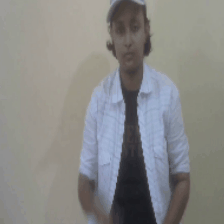

In [21]:
import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

video_tensor = sample_video["video"]
display_gif(video_tensor)
#print(video_tensor.shape)

In [22]:
import evaluate
metric = evaluate.load("accuracy")
import torch

def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions."""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)


def collate_fn(examples):
    """The collation function to be used by `Trainer` to prepare data batches."""
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
# from huggingface_hub import login, hf_hub_download


# # Authenticate using the API token
# login(token=hf_token)

# BdSLW401

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([401]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([401, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/transformers/training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_2550794/1458393764.py:176: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Train

  0%|          | 0/97180 [00:00<?, ?it/s]

{'loss': 24.0454, 'grad_norm': 19.293134689331055, 'learning_rate': 5.09364066680387e-07, 'epoch': 0.0}
{'loss': 24.0053, 'grad_norm': 21.040252685546875, 'learning_rate': 1.023873224943404e-06, 'epoch': 0.0}
{'loss': 24.0507, 'grad_norm': 19.33240509033203, 'learning_rate': 1.5383823832064212e-06, 'epoch': 0.0}
{'loss': 24.0029, 'grad_norm': 19.32372283935547, 'learning_rate': 2.0528915414694384e-06, 'epoch': 0.0}
{'loss': 24.0308, 'grad_norm': 16.2111759185791, 'learning_rate': 2.5674006997324555e-06, 'epoch': 0.01}
{'loss': 23.9547, 'grad_norm': 17.634601593017578, 'learning_rate': 3.0819098579954722e-06, 'epoch': 0.01}
{'loss': 23.9353, 'grad_norm': 16.371814727783203, 'learning_rate': 3.59641901625849e-06, 'epoch': 0.01}
{'loss': 23.8802, 'grad_norm': 17.488460540771484, 'learning_rate': 4.110928174521507e-06, 'epoch': 0.01}
{'loss': 23.9075, 'grad_norm': 22.65777587890625, 'learning_rate': 4.625437332784524e-06, 'epoch': 0.01}
{'loss': 23.8475, 'grad_norm': 24.60404396057129, 'le

2025-01-31 19:42:49,358 - INFO - Metrics: Accuracy: 0.6847, Precision: 0.7288, Recall: 0.6847, F1: 0.6538


{'eval_loss': 2.382448196411133, 'eval_accuracy': 0.6846662109820004, 'eval_precision': 0.7288455280310643, 'eval_recall': 0.6846662109820004, 'eval_f1': 0.6537984106283018, 'eval_runtime': 2494.3897, 'eval_samples_per_second': 1.76, 'eval_steps_per_second': 0.88, 'epoch': 0.05}
{'loss': 9.3033, 'grad_norm': 49.77556610107422, 'learning_rate': 2.5195513480139947e-05, 'epoch': 1.0}
{'loss': 9.2047, 'grad_norm': 51.566978454589844, 'learning_rate': 2.5710022638402965e-05, 'epoch': 1.0}
{'loss': 8.5231, 'grad_norm': 54.114253997802734, 'learning_rate': 2.622453179666598e-05, 'epoch': 1.0}
{'loss': 8.3743, 'grad_norm': 49.441165924072266, 'learning_rate': 2.6739040954929002e-05, 'epoch': 1.0}
{'loss': 7.9899, 'grad_norm': 57.128700256347656, 'learning_rate': 2.7253550113192017e-05, 'epoch': 1.0}
{'loss': 7.6113, 'grad_norm': 44.349124908447266, 'learning_rate': 2.7768059271455032e-05, 'epoch': 1.01}
{'loss': 7.205, 'grad_norm': 48.76312255859375, 'learning_rate': 2.827742333813542e-05, 'ep

...

2025-02-05 07:31:53,244 - INFO - Metrics: Accuracy: 0.9920, Precision: 0.9929, Recall: 0.9920, F1: 0.9920


{'eval_loss': 0.048131901770830154, 'eval_accuracy': 0.9920255183413078, 'eval_precision': 0.9929066446883383, 'eval_recall': 0.9920255183413078, 'eval_f1': 0.9920142597270795, 'eval_runtime': 1715.552, 'eval_samples_per_second': 2.558, 'eval_steps_per_second': 1.279, 'epoch': 18.05}
{'loss': 0.0003, 'grad_norm': 0.00015983071352820843, 'learning_rate': 2.7537673503921705e-06, 'epoch': 19.0}
{'loss': 0.0001, 'grad_norm': 0.0006006372859701514, 'learning_rate': 2.6965996661407244e-06, 'epoch': 19.0}
{'loss': 0.0, 'grad_norm': 7.218247628770769e-05, 'learning_rate': 2.639431981889278e-06, 'epoch': 19.0}
{'loss': 0.0, 'grad_norm': 6.638724153162912e-05, 'learning_rate': 2.5822642976378313e-06, 'epoch': 19.0}
{'loss': 0.054, 'grad_norm': 2.7734758853912354, 'learning_rate': 2.525096613386385e-06, 'epoch': 19.0}
{'loss': 0.0172, 'grad_norm': 0.00013950375432614237, 'learning_rate': 2.4679289291349386e-06, 'epoch': 19.01}
{'loss': 0.0, 'grad_norm': 0.0006906036287546158, 'learning_rate': 2.4

2025-02-05 12:24:37,545 - INFO - Metrics: Accuracy: 0.9920, Precision: 0.9928, Recall: 0.9920, F1: 0.9920


{'eval_loss': 0.047321777790784836, 'eval_accuracy': 0.9920255183413078, 'eval_precision': 0.9927718114195337, 'eval_recall': 0.9920255183413078, 'eval_f1': 0.9920074475652422, 'eval_runtime': 1675.5094, 'eval_samples_per_second': 2.62, 'eval_steps_per_second': 1.31, 'epoch': 19.05}
{'train_runtime': 431394.6922, 'train_samples_per_second': 1.802, 'train_steps_per_second': 0.225, 'train_loss': 1.2732148697320314, 'epoch': 19.05}


2025-02-05 16:28:16,689 - INFO - Metrics: Accuracy: 0.9997, Precision: 0.9997, Recall: 0.9997, F1: 0.9997
2025-02-05 16:28:16,701 - INFO - Training Metrics - Accuracy: 0.9997, Precision: 0.9997, Recall: 0.9997, F1: 0.9997


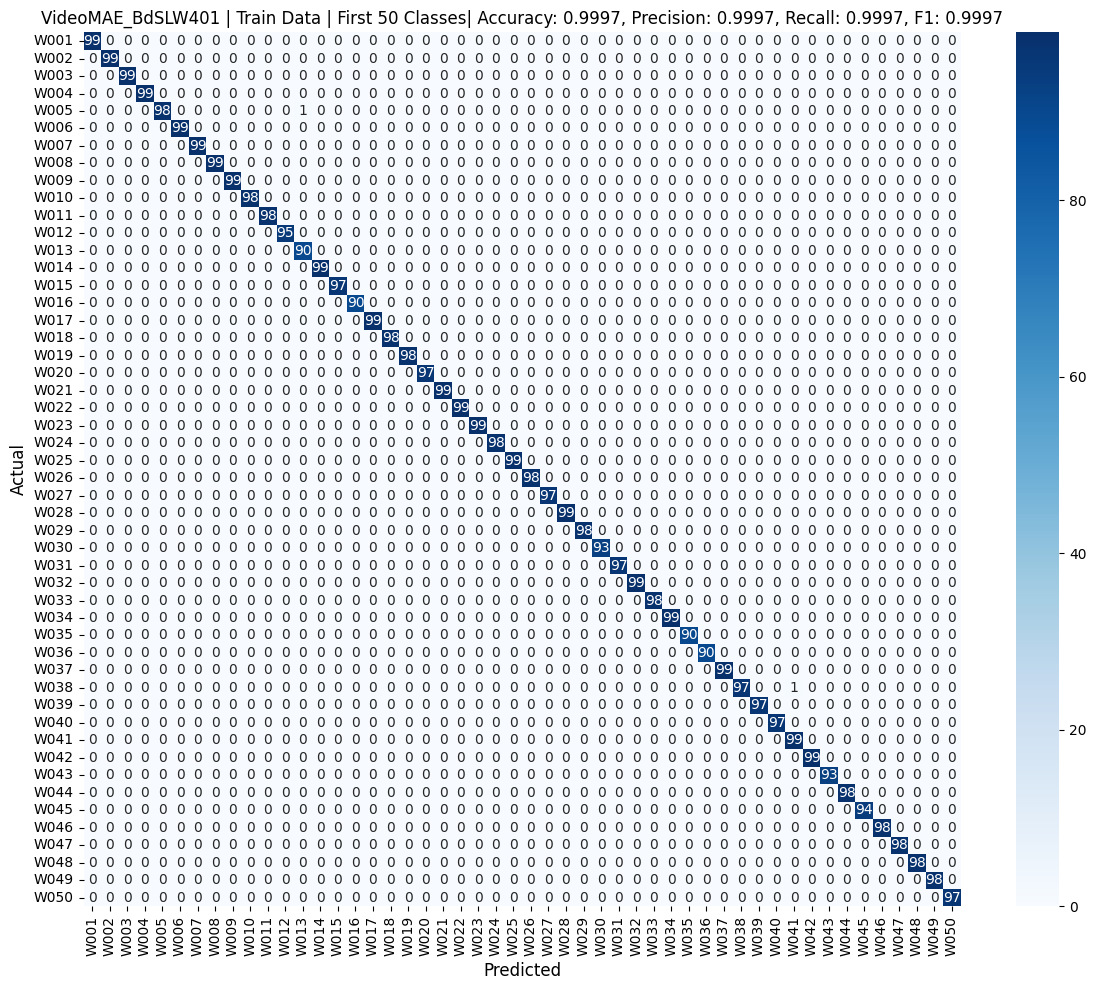

2025-02-05 16:55:59,805 - INFO - Metrics: Accuracy: 0.9920, Precision: 0.9929, Recall: 0.9920, F1: 0.9920
2025-02-05 16:55:59,808 - INFO - Validation Metrics - Accuracy: 0.9920, Precision: 0.9929, Recall: 0.9920, F1: 0.9920


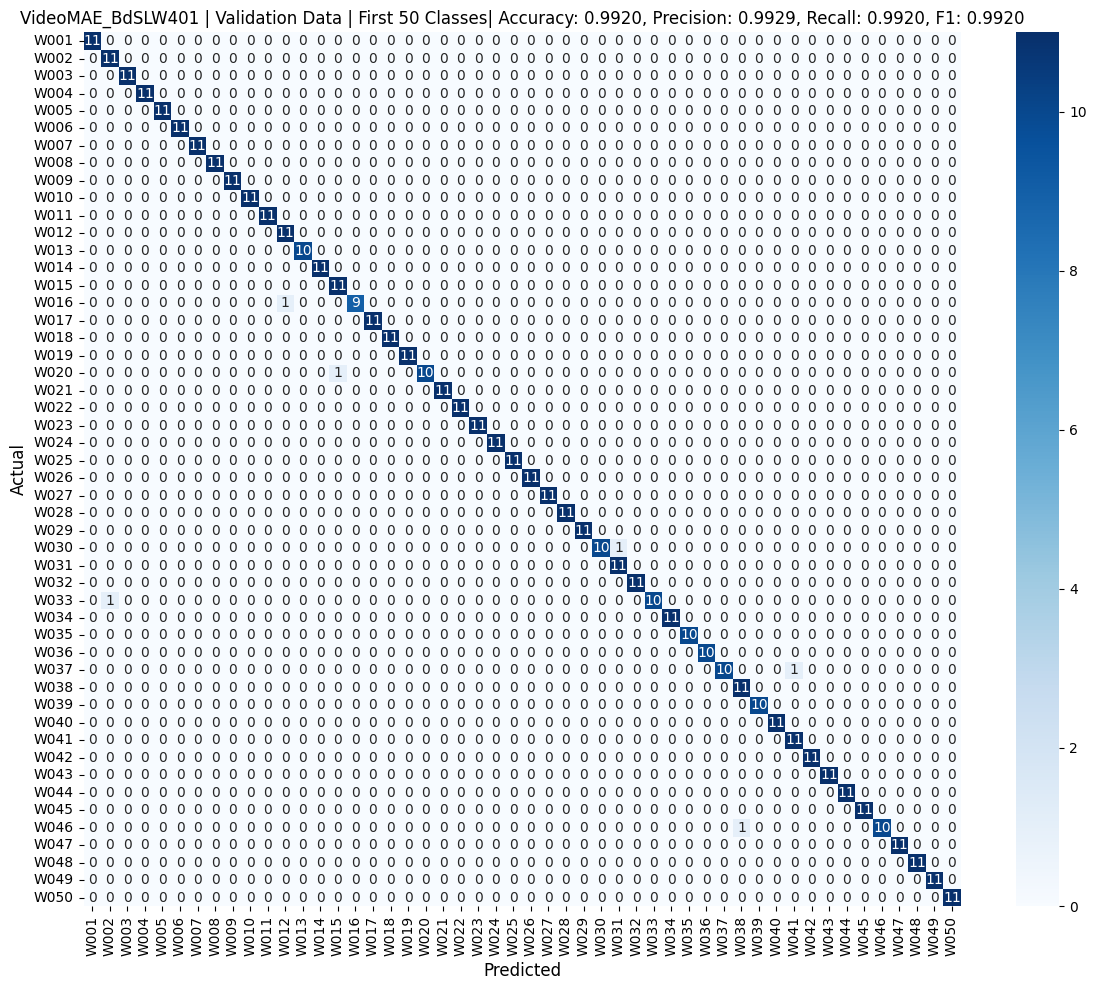

2025-02-05 17:41:48,062 - INFO - Metrics: Accuracy: 0.8104, Precision: 0.8457, Recall: 0.8104, F1: 0.8014
2025-02-05 17:41:48,067 - INFO - Test Metrics - Accuracy: 0.8104, Precision: 0.8457, Recall: 0.8104, F1: 0.8014


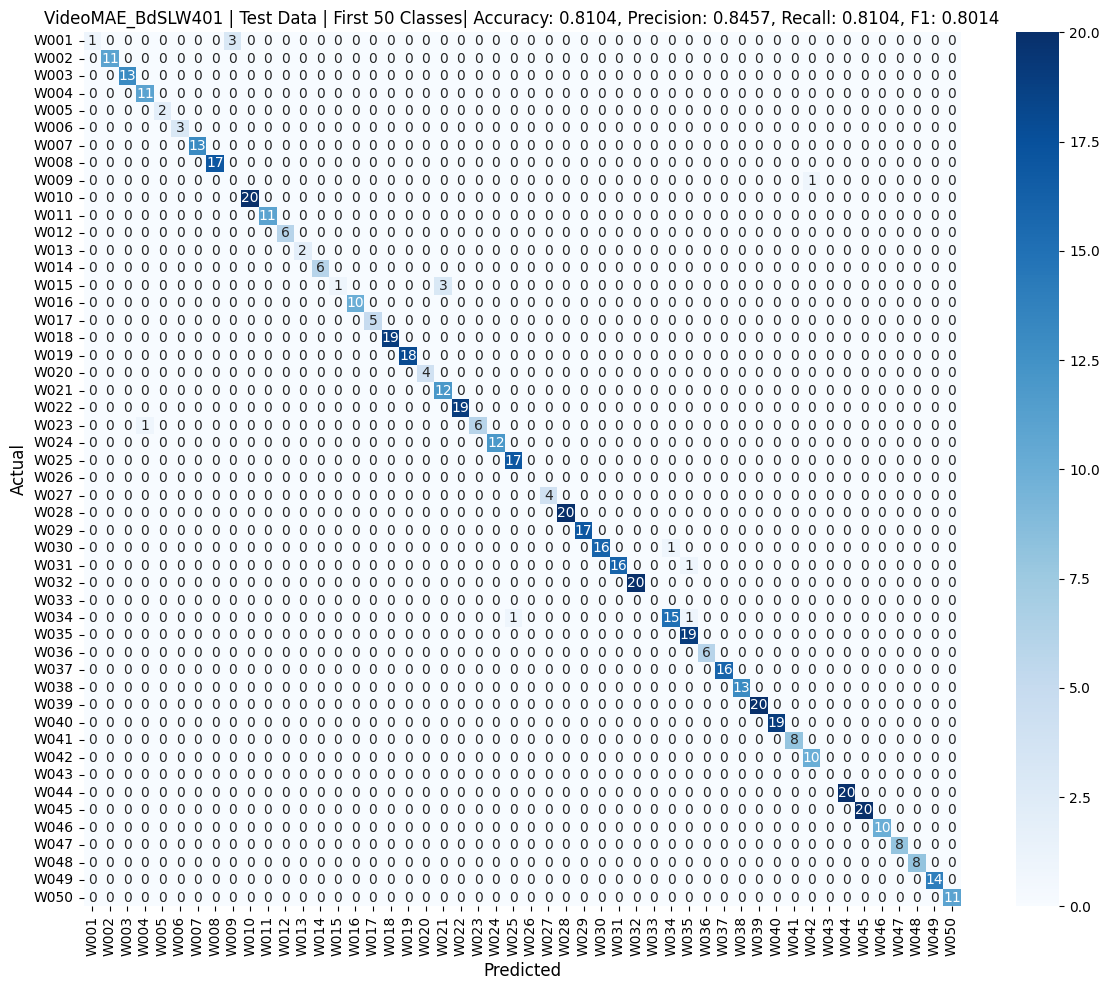

***** test metrics *****
  accuracy  = 0.8104
  f1        = 0.8014
  precision = 0.8457
  recall    = 0.8104


2025-02-05 17:41:56,815 - INFO - Training complete. Model and checkpoints saved in: /media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_BdSLW401_20_epochs_p5_SR_10


Training complete. Model and checkpoints saved in: /media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_BdSLW401_20_epochs_p5_SR_10


In [ ]:
import os
import torch
import logging
import matplotlib.pyplot as plt
import numpy as np
from transformers import Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
from transformers import EarlyStoppingCallback, AutoImageProcessor, VideoMAEForVideoClassification, VideoMAEImageProcessor
import seaborn as sns
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)
import logging
from transformers import Trainer

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

num_epochs = 20

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and image processor
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)


model.to(device)

# Output directory for checkpoints
output_checkpoint_dir = r"/media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_BdSLW401_20_epochs_p5_SR_10"
os.makedirs(output_checkpoint_dir, exist_ok=True)



def plot_confusion_matrix(
    conf_matrix, 
    class_labels, 
    accuracy=None, 
    precision=None, 
    recall=None, 
    f1=None, 
    dataset_name="Test Data", 
    normalize=False, 
    filename="confusion_matrix.png", 
    subset_size=None
):

    # Subset the confusion matrix and labels if subset_size is specified
    if subset_size:
        conf_matrix = conf_matrix[:subset_size, :subset_size]
        class_labels = class_labels[:subset_size]

    if normalize:
        conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels)

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)

    # Create title with metrics
    title = f"VideoMAE_BdSLW401 | {dataset_name} | First 50 Classes| Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    plt.title(title)

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()


def compute_metrics(p):
    
    preds = p.predictions
    labels = p.label_ids

    # Argmax predictions for precision/recall/F1
    preds_argmax = np.argmax(preds, axis=1)

    # Calculate precision, recall, and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds_argmax, average='weighted', zero_division=0
    )
    accuracy = accuracy_score(labels, preds_argmax)

    # Log metrics
    logging.info(
        f"Metrics: Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Training arguments
#batch_size = 32
args = TrainingArguments(
    output_dir=output_checkpoint_dir,
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_ratio=0.1,
    logging_steps=100,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    load_best_model_at_end=True,
    max_steps=(train_dataset.num_videos // (2*4)) * num_epochs,  # Dynamically calculate max_steps
    report_to="none",
    fp16=True,
    weight_decay=0.01,
)

# Trainer initialization
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

# Train the model
trainer.train()
trainer.save_model()



# ------------------- TRAINING METRICS -------------------
train_predictions = trainer.predict(train_dataset)
train_preds = train_predictions.predictions
train_labels = train_predictions.label_ids

train_preds_argmax = np.argmax(train_preds, axis=1)
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
    train_labels, train_preds_argmax, average='weighted', zero_division=0
)
train_accuracy = accuracy_score(train_labels, train_preds_argmax)

logging.info(
    f"Training Metrics - Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}"
)

plot_confusion_matrix(
    conf_matrix=confusion_matrix(train_labels, train_preds_argmax),
    class_labels=list(id2label.values()),
    accuracy=train_accuracy,
    precision=train_precision,
    recall=train_recall,
    f1=train_f1,
    dataset_name="Train Data",
    filename="confusion_matrix_train.png",
    subset_size=50  # Visualize only the first 50 classes
)


# ------------------- VALIDATION METRICS -------------------
val_predictions = trainer.predict(val_dataset)
val_preds = val_predictions.predictions
val_labels = val_predictions.label_ids

val_preds_argmax = np.argmax(val_preds, axis=1)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    val_labels, val_preds_argmax, average='weighted', zero_division=0
)
val_accuracy = accuracy_score(val_labels, val_preds_argmax)

logging.info(
    f"Validation Metrics - Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}"
)

plot_confusion_matrix(
    conf_matrix=confusion_matrix(val_labels, val_preds_argmax),
    class_labels=list(id2label.values()),
    accuracy=val_accuracy,
    precision=val_precision,
    recall=val_recall,
    f1=val_f1,
    dataset_name="Validation Data",
    filename="confusion_matrix_valid.png",
    subset_size=50  # Visualize only the first 50 classes
)

# ------------------- TEST METRICS -------------------
test_predictions = trainer.predict(test_dataset)
test_preds = test_predictions.predictions
test_labels = test_predictions.label_ids

test_preds_argmax = np.argmax(test_preds, axis=1)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_preds_argmax, average='weighted', zero_division=0
)
test_accuracy = accuracy_score(test_labels, test_preds_argmax)

logging.info(
    f"Test Metrics - Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}"
)

plot_confusion_matrix(
    conf_matrix=confusion_matrix(test_labels, test_preds_argmax),
    class_labels=list(id2label.values()),
    accuracy=test_accuracy,
    precision=test_precision,
    recall=test_recall,
    f1=test_f1,
    dataset_name="Test Data",
    filename="confusion_matrix_test.png",
    subset_size=50  # Visualize only the first 50 classes
)



# Full confusion matrix saved as CSV
# import pandas as pd
# pd.DataFrame(confusion_matrix(test_labels, test_preds_argmax), index=class_labels, columns=class_labels).to_csv("confusion_matrix_full.csv")

# Save results
test_results = {
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
}

# Log and save metrics
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
trainer.save_state()
trainer.push_to_hub()

logging.info(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
print(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
